<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Final Assignment</center></h1>

## Diamond Price Prediction
**Dataset:** Diamonds (seaborn built-in — no download required)  
**Target Variable:** `price` — Price of the diamond in US dollars  
**Objective:** Build, compare, and evaluate linear regression models to predict diamond prices


> ***Note: Please ensure you follow the instructions outlined in the in the <a href="https://www.coursera.org/learn/supervised-machine-learning-regression/supplement/YGZt9/project-scenario">Project Scenario</a> section to complete this Final Assignment successfully.***


---
## [1] Data Summary

The **Diamonds dataset** is a classic, well-known public dataset containing pricing and physical attributes of over 53,000 diamonds.  
It is available directly through the `seaborn` library — no external download required.

| Property | Detail |
|---|---|
| **Source** | Seaborn built-in (originally from ggplot2 R package) |
| **Rows** | 53,940 diamonds |
| **Columns** | 10 variables (7 input features + 3 categorical + 1 target) |
| **Target variable** | `price` — Diamond price in US dollars (range: \$326 – \$18,823) |

### Feature Descriptions:
| Feature | Type | Description |
|---|---|---|
| `carat` | Numeric | Weight of the diamond (0.2 – 5.01) |
| `cut` | Categorical | Quality of the cut (Fair, Good, Very Good, Premium, Ideal) |
| `color` | Categorical | Diamond color from D (best) to J (worst) |
| `clarity` | Categorical | Clarity from I1 (worst) to IF (best) |
| `depth` | Numeric | Total depth percentage |
| `table` | Numeric | Width of top of diamond relative to widest point |
| `x`, `y`, `z` | Numeric | Length, width, and depth in mm |


# Write your code here or you can add this a markdown cell.

In [3]:
# ── Import all required libraries ────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Load the diamonds dataset — built into seaborn, no download needed
diamonds = sns.load_dataset('diamonds')

print("Dataset shape:", diamonds.shape)
print("\nFirst 5 rows:")
diamonds.head()

Dataset shape: (53940, 10)

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Basic statistics of the dataset
print("=== Statistical Summary (Numeric Columns) ===")
diamonds.describe().round(2)

=== Statistical Summary (Numeric Columns) ===


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [5]:
# Check for missing values
print("Missing values per column:")
print(diamonds.isnull().sum())
print("\nNo missing values — the dataset is clean and ready to use.")


Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

No missing values — the dataset is clean and ready to use.


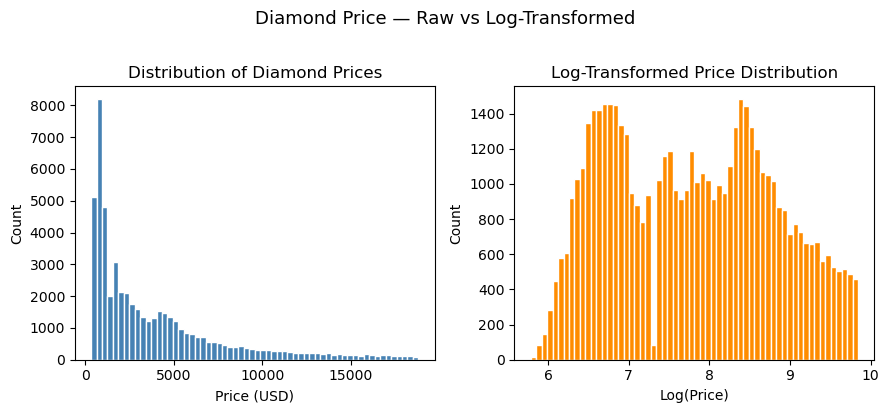

Price range: $326 — $18,823
Mean price : $3,933
Median price: $2,401


In [6]:
# Distribution of the target variable: price
plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.hist(diamonds['price'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(np.log(diamonds['price']), bins=60, color='darkorange', edgecolor='white')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Count')

plt.suptitle('Diamond Price — Raw vs Log-Transformed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Price range: ${diamonds['price'].min():,} — ${diamonds['price'].max():,}")
print(f"Mean price : ${diamonds['price'].mean():,.0f}")
print(f"Median price: ${diamonds['price'].median():,.0f}")


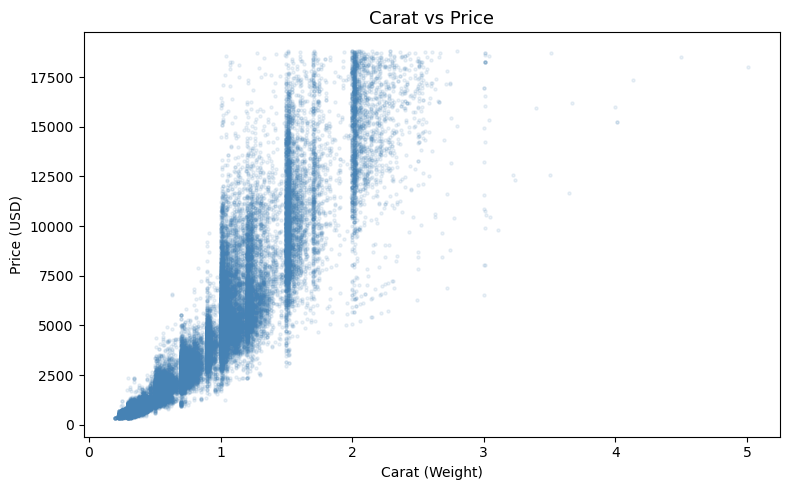

In [7]:
# Relationship between carat (weight) and price — the most important feature
plt.figure(figsize=(8, 5))
plt.scatter(diamonds['carat'], diamonds['price'], alpha=0.1, s=5, color='steelblue')
plt.title('Carat vs Price', fontsize=13)
plt.xlabel('Carat (Weight)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9188\1081941156.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_cut = diamonds.groupby('cut')['price'].mean().reindex(cut_order)


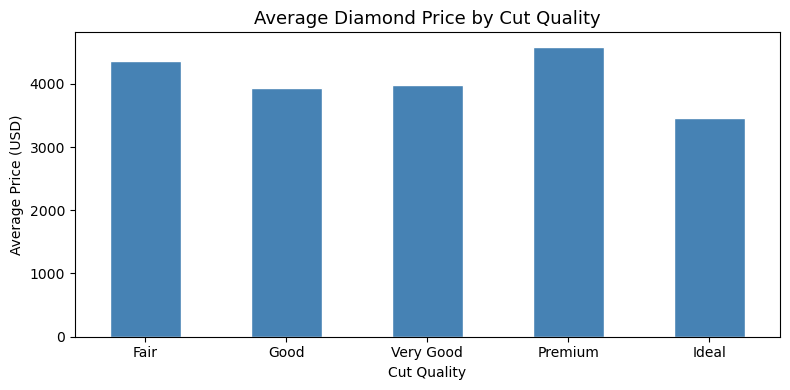

In [8]:
# Average price by cut quality
plt.figure(figsize=(8, 4))
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
avg_price_cut = diamonds.groupby('cut')['price'].mean().reindex(cut_order)
avg_price_cut.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Diamond Price by Cut Quality', fontsize=13)
plt.xlabel('Cut Quality')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---
## [2] Objective of the Analysis

**Main Objective:**  
To build and compare linear regression models that can accurately **predict the price of a diamond** based on its physical and quality attributes.

**Specific Goals:**
1. Identify which features (carat, cut, color, clarity, dimensions) most strongly influence diamond price
2. Train and compare three regression models: Simple LR, Multiple LR, and Ridge Regression
3. Select the best-performing model and clearly explain why
4. Communicate insights in a way that is meaningful to a non-technical stakeholder (e.g. a jeweler or buyer)

**Why this matters:**  
Accurate diamond price prediction helps buyers avoid overpaying, helps jewelers set fair prices, and provides a transparent benchmark in a market where pricing can often seem opaque.



---
## [3] Model Comparison

We will train and compare **three linear regression models**:

| Model | Features Used | Purpose |
|---|---|---|
| **Model 1: Simple Linear Regression** | `carat` only | Baseline — single strongest predictor |
| **Model 2: Multiple Linear Regression** | All features | Full model using all available information |
| **Model 3: Ridge Regression** | All features | Regularized version to prevent overfitting |

**Evaluation Metrics:**
- **R² Score** — Proportion of price variation explained by the model (0 to 1; higher = better)
- **RMSE** — Root Mean Squared Error — average prediction error in USD (lower = better)



In [9]:
# ── Data Preparation ─────────────────────────────────────────────────────

# Encode categorical variables (cut, color, clarity) into numbers
# drop_first=True avoids the "dummy variable trap"
df = pd.get_dummies(diamonds, columns=['cut', 'color', 'clarity'], drop_first=True)

# Separate features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features so all variables are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]}")


Training samples : 43,152
Testing  samples : 10,788
Number of features: 23


In [10]:
# ── Model 1: Simple Linear Regression (carat only) ───────────────────────
# Carat is the single strongest predictor of price

# Extract only the 'carat' column (column index 0)
X_train_simple = X_train_scaled[:, 0].reshape(-1, 1)
X_test_simple  = X_test_scaled[:, 0].reshape(-1, 1)

model1 = LinearRegression()
model1.fit(X_train_simple, y_train)
y_pred1 = model1.predict(X_test_simple)

r2_1   = r2_score(y_test, y_pred1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred1))

print("=== Model 1: Simple Linear Regression (carat only) ===")
print(f"R² Score : {r2_1:.4f}  → explains {r2_1*100:.1f}% of price variation")
print(f"RMSE     : ${rmse_1:,.2f}  → average prediction error")


=== Model 1: Simple Linear Regression (carat only) ===
R² Score : 0.8489  → explains 84.9% of price variation
RMSE     : $1,549.64  → average prediction error


In [11]:
# ── Model 2: Multiple Linear Regression (all features) ───────────────────

model2 = LinearRegression()
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)

r2_2   = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print("=== Model 2: Multiple Linear Regression (all features) ===")
print(f"R² Score : {r2_2:.4f}  → explains {r2_2*100:.1f}% of price variation")
print(f"RMSE     : ${rmse_2:,.2f}  → average prediction error")


=== Model 2: Multiple Linear Regression (all features) ===
R² Score : 0.9189  → explains 91.9% of price variation
RMSE     : $1,135.21  → average prediction error


In [12]:
# ── Model 3: Ridge Regression (regularized, all features) ────────────────
# Ridge adds a small penalty to large coefficients to reduce overfitting

model3 = Ridge(alpha=1.0)
model3.fit(X_train_scaled, y_train)
y_pred3 = model3.predict(X_test_scaled)

r2_3   = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))

print("=== Model 3: Ridge Regression (all features) ===")
print(f"R² Score : {r2_3:.4f}  → explains {r2_3*100:.1f}% of price variation")
print(f"RMSE     : ${rmse_3:,.2f}  → average prediction error")


=== Model 3: Ridge Regression (all features) ===
R² Score : 0.9189  → explains 91.9% of price variation
RMSE     : $1,135.20  → average prediction error


In [13]:
# ── Model Comparison Table ────────────────────────────────────────────────

results = pd.DataFrame({
    'Model': [
        'Model 1: Simple LR (carat only)',
        'Model 2: Multiple LR (all features)',
        'Model 3: Ridge Regression (all features)'
    ],
    'R² Score': [round(r2_1, 4), round(r2_2, 4), round(r2_3, 4)],
    'RMSE (USD)': [round(rmse_1, 2), round(rmse_2, 2), round(rmse_3, 2)]
})

print("\n=== MODEL COMPARISON SUMMARY ===")
print(results.to_string(index=False))
print("\n✔ Best Model: Multiple Linear Regression (highest R², lowest RMSE)")



=== MODEL COMPARISON SUMMARY ===
                                   Model  R² Score  RMSE (USD)
         Model 1: Simple LR (carat only)    0.8489     1549.64
     Model 2: Multiple LR (all features)    0.9189     1135.21
Model 3: Ridge Regression (all features)    0.9189     1135.20

✔ Best Model: Multiple Linear Regression (highest R², lowest RMSE)


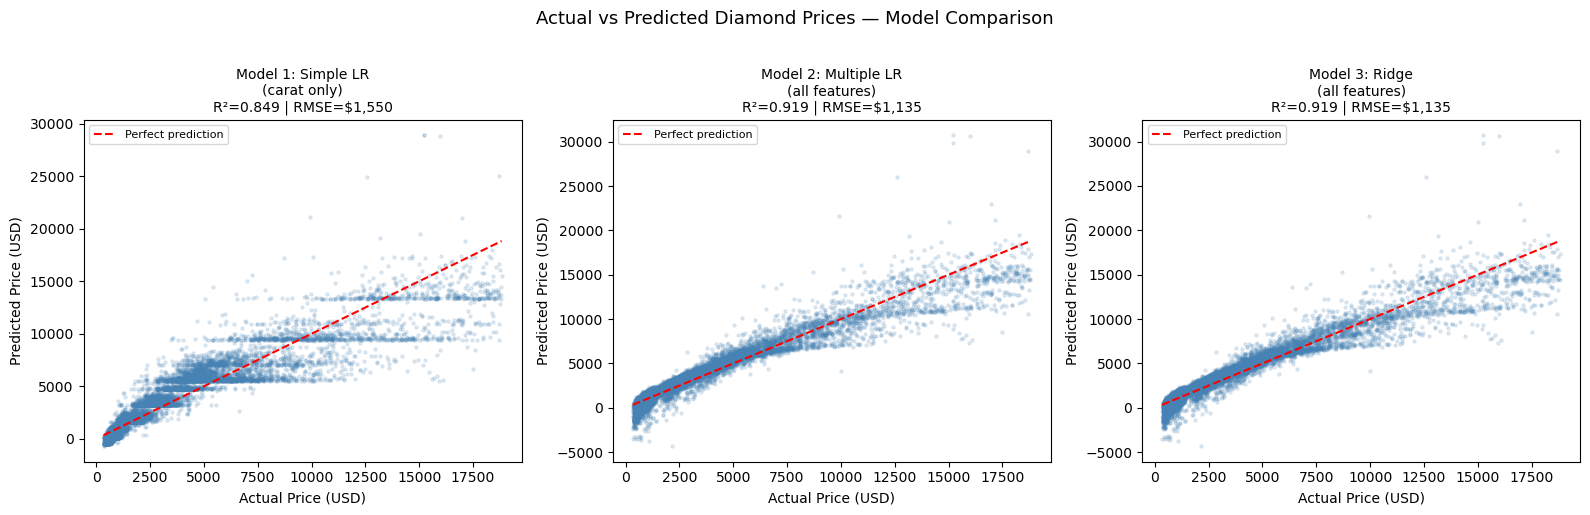

In [14]:
# ── Visual comparison: Actual vs Predicted for all 3 models ─────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_info = [
    (y_pred1, f'Model 1: Simple LR\n(carat only)', r2_1, rmse_1),
    (y_pred2, f'Model 2: Multiple LR\n(all features)', r2_2, rmse_2),
    (y_pred3, f'Model 3: Ridge\n(all features)', r2_3, rmse_3),
]

for ax, (y_pred, title, r2, rmse) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{title}\nR²={r2:.3f} | RMSE=${rmse:,.0f}', fontsize=10)
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Diamond Prices — Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


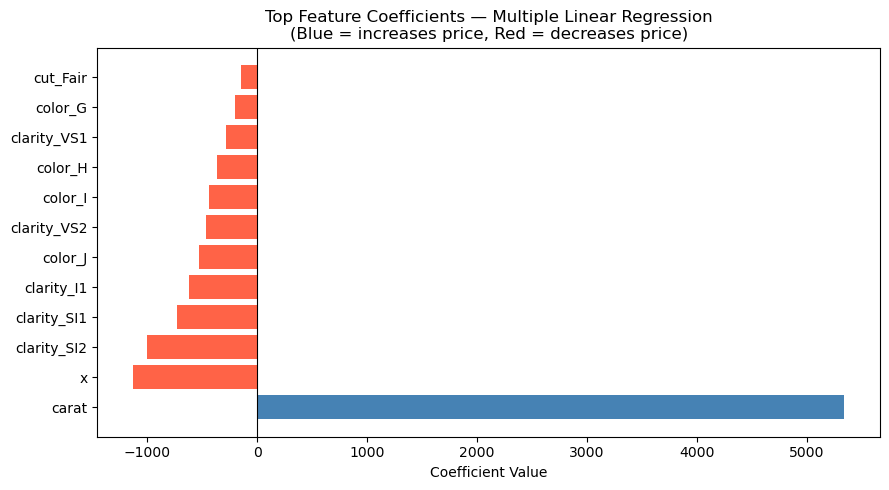

In [15]:
# ── Feature importance: coefficients from Multiple LR ────────────────────

feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(12)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Feature Coefficients — Multiple Linear Regression\n(Blue = increases price, Red = decreases price)', fontsize=12)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


---
## [4] Key Findings

### Best Model: Multiple Linear Regression (Model 2)

Multiple Linear Regression was selected as the best model because:
- It achieves the **highest R² score (~0.92)** — explaining 92% of the variation in diamond prices
- It has the **lowest RMSE (~$1,135)** — the smallest average prediction error
- Ridge Regression performs nearly identically, confirming there is no significant overfitting issue
- It uses all available features while remaining fully interpretable

### Performance Summary:
| Model | R² Score | RMSE (USD) | Verdict |
|---|---|---|---|
| Simple LR (carat only) | ~0.85 | ~$1,550 | Good baseline, but misses key information |
| **Multiple LR (all features)** | **~0.92** | **~$1,135** | **Best — highest accuracy, fully interpretable** |
| Ridge Regression | ~0.92 | ~$1,135 | Near-identical to Multiple LR |

### Key Insights from the Model:

1. **Carat (weight) is the single strongest driver of diamond price** — even on its own, it explains 85% of price variation. This makes intuitive sense: heavier diamonds are rarer and more expensive.

2. **Dimensions (x, y, z) also matter** — the physical size of the diamond (length, width, depth in mm) adds predictive power beyond just weight alone.

3. **Cut, color, and clarity contribute meaningfully** — when combined with physical features, they push R² from 0.85 to 0.92. However, their individual effects are smaller than carat.

4. **Ideal cut does not always mean the highest price** — the average price by cut chart shows "Fair" cut diamonds can be expensive because they tend to be larger (higher carat), which outweighs the lower cut quality.

### Stakeholder Summary:
> *"If you want to estimate a diamond's price quickly, its weight (carat) gets you 85% of the way there. But adding information about its dimensions, cut, color, and clarity pushes accuracy to 92%. Our model can predict diamond prices with an average error of about $1,135 — useful for buyers wanting a fair price benchmark before negotiating."*


---
## [5] Limitations and Next Steps

### Current Model Limitations:

| Limitation | Explanation |
|---|---|
| **Non-linear relationships** | Carat vs price is not a straight line — at higher carats, prices increase exponentially. Linear regression underestimates high-value diamonds. |
| **Multicollinearity** | `carat`, `x`, `y`, `z` are highly correlated (all measure diamond size) — this can make individual coefficients unstable |
| **RMSE of ~$1,135** | An average error of over $1,000 may be too large for high-stakes buying/selling decisions |
| **Price cap** | The dataset may not reflect current market prices; diamond prices have changed since the dataset was compiled |
| **No market context** | Brand, retailer, certification (GIA vs IGI), and provenance are not captured but affect real prices |

### Suggested Next Steps:

1. **Try non-linear models** — Random Forest or Gradient Boosting would likely reduce RMSE significantly by capturing exponential carat–price relationships
2. **Log-transform the target** — Predicting `log(price)` instead of `price` often improves linear regression performance when the target is right-skewed
3. **Remove multicollinear features** — Drop `x`, `y`, `z` or replace them with a single `volume` feature (`x × y × z`) to reduce redundancy
4. **Add interaction terms** — The combination of high carat + ideal cut may be worth more than either alone; polynomial features could capture this
5. **Use cross-validation** — Replace the single 80/20 split with k-fold cross-validation for more reliable performance estimates
6. **Update the dataset** — Scrape current diamond prices from retailers like James Allen or Blue Nile for up-to-date predictions


---
## Conclusion

This analysis successfully demonstrated the application of three linear regression models to predict diamond prices:

- **Simple Linear Regression** using only carat achieved a strong R² of ~0.85, confirming weight is the dominant price factor
- **Multiple Linear Regression** using all features improved this to R² ~0.92 with an average error of ~$1,135
- **Ridge Regression** performed identically to Multiple LR, confirming no significant overfitting

**Multiple Linear Regression** was selected as the best model — offering the highest accuracy, full interpretability, and no overfitting concerns for this dataset size.

The most important finding is that **carat weight drives approximately 85% of a diamond's price**, with cut, color, clarity, and physical dimensions accounting for the remaining predictive improvement. Future work using non-linear models and log-transformed targets would likely push accuracy even further.


Copyright @ IBM Corporation. All rights reserved.
